## Part 3: NumPy model (Davis)

Fit fuel use against speed for **vehicle 531** using NumPy ordinary least squares. The quadratic model is

$$\text{fuel\_use} = w_2\,\text{speed}^2 + w_1\,\text{speed} + b.$$

It is polynomial in speed but linear in the unknown weights. The design matrix columns are `[speed², speed, 1]`, so `np.linalg.lstsq` returns `[w₂, w₁, b]` in that order.

## Data

The fit uses the team's shared modelling data: `speed_df` from Part 1 (`main.ipynb`), with the `speed_sq` column added by Rangeetha's `PolynomialTransformer` from Part 2. Each of the 76 rows is the average fuel use (L/100 km) at one speed from 10 to 85 km/h, built from 308,021 cleaned readings. The cleaning rules (idling removed, speeds below 10 km/h removed, speeds with fewer than 100 readings dropped) are documented in Part 1.

In [1]:
%%capture
# Run Part 1 to rebuild speed_df. Its printed output is hidden here; see main.ipynb.
%run main.ipynb

In [2]:
from transform_analysis import PolynomialTransformer

speed_df = PolynomialTransformer().transform(speed_df)

required_columns = {"speed", "speed_sq", "fuel_use"}
missing_columns = required_columns.difference(speed_df.columns)
if missing_columns:
    raise ValueError(f"speed_df is missing required columns: {sorted(missing_columns)}")
if len(speed_df) < 3:
    raise ValueError("At least three observations are needed for a quadratic fit.")

print("Vehicle 531, speed averages from Part 1")
print(f"Rows: {len(speed_df)}")
print(f"Speed range: {speed_df['speed'].min():.0f} to {speed_df['speed'].max():.0f} km/h")

Vehicle 531, speed averages from Part 1
Rows: 76
Speed range: 10 to 85 km/h


## Build the design matrix and fit

For each observation, one design-matrix row is `[speed², speed, 1]`. Least squares chooses weights that minimize the sum of squared differences between observed and predicted fuel use.

In [3]:
speed = speed_df["speed"].to_numpy(dtype=float)
speed_sq = speed_df["speed_sq"].to_numpy(dtype=float)
fuel_use = speed_df["fuel_use"].to_numpy(dtype=float)

design_matrix = np.column_stack((speed_sq, speed, np.ones_like(speed)))
weights, residual_sum_squares, rank, singular_values = np.linalg.lstsq(
    design_matrix, fuel_use, rcond=None
)
w2, w1, b = weights
fuel_use_pred = design_matrix @ weights

print("Design matrix columns: [speed², speed, 1]")
print(f"Design matrix shape: {design_matrix.shape}")
print(f"Rank: {rank}")
print(f"w₂ = {w2:.8f} L/100km per (km/h)²")
print(f"w₁ = {w1:.8f} L/100km per (km/h)")
print(f"b  = {b:.8f} L/100km")
print(f"Least-squares residual sum of squares: {residual_sum_squares[0]:.8f}")

Design matrix columns: [speed², speed, 1]
Design matrix shape: (76, 3)
Rank: 3
w₂ = 0.00410078 L/100km per (km/h)²
w₁ = -0.54621979 L/100km per (km/h)
b  = 23.13883385 L/100km
Least-squares residual sum of squares: 14.15088685


## Predictions and interpretation

The plot overlays the NumPy predictions on the 76 speed averages used for fitting.

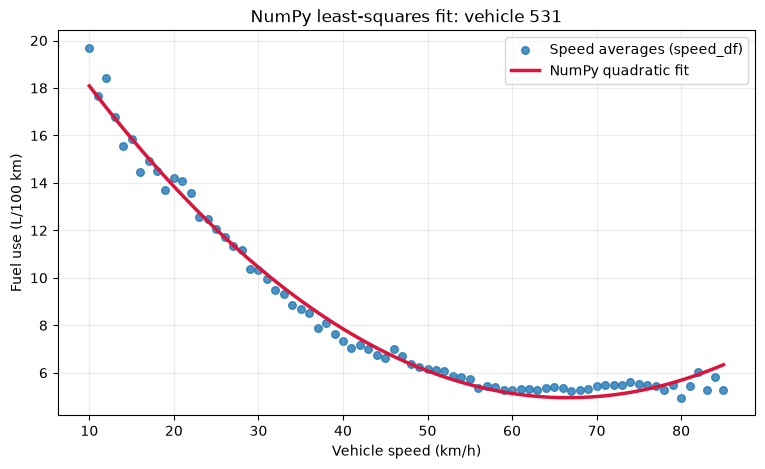

In [4]:
speed_line = np.linspace(speed.min(), speed.max(), 300)
design_line = np.column_stack((speed_line**2, speed_line, np.ones_like(speed_line)))
fuel_use_line = design_line @ weights

plt.figure(figsize=(9, 5))
plt.scatter(speed, fuel_use, s=30, alpha=0.8, label="Speed averages (speed_df)")
plt.plot(speed_line, fuel_use_line, color="crimson", linewidth=2.5, label="NumPy quadratic fit")
plt.xlabel("Vehicle speed (km/h)")
plt.ylabel("Fuel use (L/100 km)")
plt.title("NumPy least-squares fit: vehicle 531")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### What the weights mean

The weights describe the curve as a whole, so we read them together rather than one at a time:

- **b** is the curve's value at 0 km/h. That is outside the 10–85 km/h data, so it only anchors the curve and has no physical meaning on its own.
- **w₁ < 0**: at low speed, fuel use falls as speed rises.
- **w₂ > 0**: the curve bends upward (a U-shape), so the fall slows down and eventually turns into a rise.
- The slope at any speed is `2·w₂·speed + w₁`. It is zero at `speed = −w₁ / (2·w₂)`, the speed with the lowest predicted fuel use.

In [5]:
best_speed = -w1 / (2 * w2)
best_fuel_use = w2 * best_speed**2 + w1 * best_speed + b

print(f"Lowest predicted fuel use: {best_fuel_use:.2f} L/100km at {best_speed:.1f} km/h")
for s in (20, 50, 80):
    slope = 2 * w2 * s + w1
    print(f"At {s} km/h: predicted {w2 * s**2 + w1 * s + b:.2f} L/100km, slope {slope:+.3f} L/100km per km/h")

Lowest predicted fuel use: 4.95 L/100km at 66.6 km/h
At 20 km/h: predicted 13.85 L/100km, slope -0.382 L/100km per km/h
At 50 km/h: predicted 6.08 L/100km, slope -0.136 L/100km per km/h
At 80 km/h: predicted 5.69 L/100km, slope +0.110 L/100km per km/h


### Handoff to the model-checking section

The fitted coefficients are available as `w2`, `w1`, and `b`; predictions on the 76 speed averages are in `fuel_use_pred`, in the same row order as `speed_df`. The NumPy design-matrix column order is `[speed², speed, 1]`. The model comparison, R²/RMSE metrics, and residual plots belong in Part 4.

The curve is only supported between 10 and 85 km/h. Predictions outside that range are extrapolation (lab §6).